# Computer Vision Assignment 1

**Problem Statement:** Lane Detection Using Classical CV and ML Techniques  
**Dataset:** Kaggle Lane Detection Dataset (50 images) <br>
**Date:** December 11, 2025 <br>
**Group** 111



## Individual Student Contributions


| Student Name | Roll Number | Percentage |
|--------------|-------------|------------|
| Guruprasad B | 2024AA05473 | 100% |
| Srinivasan Ganesan | 2024AB05156 | 100% |
| Baranidharan S| 2024AA05253 | 100% |
| Sudhakar J | 2024AA05616 | 100% |
| Sravan Ram M S | 2024AB05169 | 100% |



### Import required libraries

In [1]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import math
from sklearn.cluster import KMeans

### Utility: display image

In [2]:
def show_image(title, img, cmap=None):
    plt.figure(figsize=(6, 4))
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    else:
        plt.imshow(img, cmap=cmap or "gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

### Dataset paths

In [26]:
image_folder = r"C:\Users\GURU\Desktop\Cv project\archive\road_line_images\road_line_images"

image_paths = glob.glob(os.path.join(image_folder, "*.jpg")) + \
              glob.glob(os.path.join(image_folder, "*.png"))

if len(image_paths) == 0:
    raise FileNotFoundError(f"No images found in folder: {image_folder}")

print("Total images:", len(image_paths))

Total images: 50


### Part 1 – Preprocessing and Edge Detection (detailed on first image)

#### 1.1 Load first image and visualize


Using image: C:\Users\GURU\Desktop\Cv project\archive\road_line_images\1\dc_vehicle_GWL9GSAFR7GZZ2O7.jpg


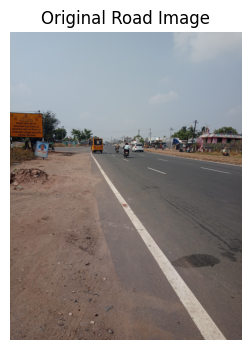

In [4]:
image_path = image_paths[0]
print(f"\nUsing image: {image_path}")
image_bgr = cv2.imread(image_path)
if image_bgr is None:
    raise RuntimeError("Could not read image")

image_original = image_bgr.copy()
show_image("Original Road Image", image_bgr)


#### 1.2 HLS conversion and white color masking

##### We convert to HLS and create a mask that keeps only bright, low‑saturation pixels.
##### This enhances the visibility of white lane markings and suppresses soil/background.

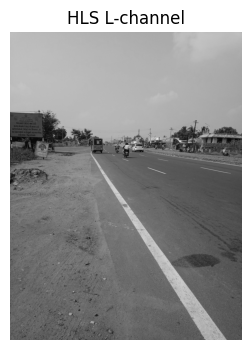

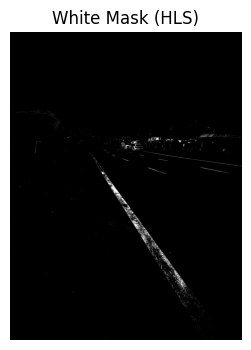

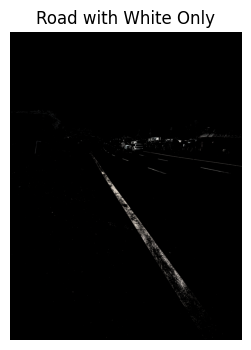

In [5]:
image_hls = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HLS)
H, L, S = cv2.split(image_hls)
show_image("HLS L-channel", L, cmap="gray")

# Threshold for near‑white lane paint (tuned experimentally)
white_mask = cv2.inRange(image_hls,
                         (0, 200, 0),      # H, L, S lower
                         (255, 255, 120))  # H, L, S upper
show_image("White Mask (HLS)", white_mask, cmap="gray")

white_only = cv2.bitwise_and(image_bgr, image_bgr, mask=white_mask)
show_image("Road with White Only", white_only)


### 1.3 Grayscale conversion and Gaussian blur

##### We convert the masked image to grayscale and apply Gaussian blur to reduce noise before running the Canny edge detector.


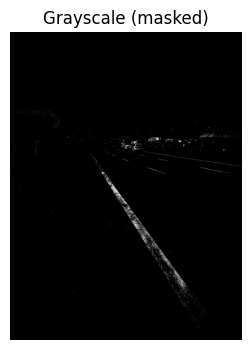

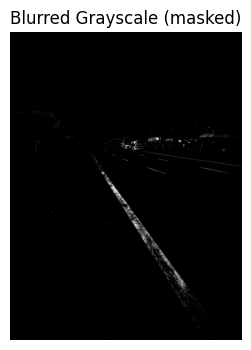

In [6]:
gray = cv2.cvtColor(white_only, cv2.COLOR_BGR2GRAY)
show_image("Grayscale (masked)", gray, cmap="gray")

gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)
show_image("Blurred Grayscale (masked)", gray_blur, cmap="gray")


### 1.4 HSV visualization 

##### We also show the HSV V-channel to illustrate brightness information in another color space.

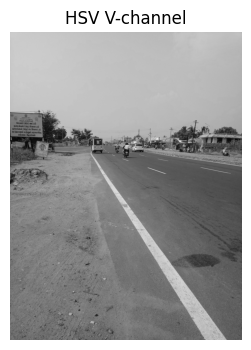

In [7]:
image_hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
hsv_v = image_hsv[:, :, 2]
show_image("HSV V-channel", hsv_v, cmap="gray")


### 1.5 Canny edge detection

##### We run Canny on the blurred grayscale image using tuned low and high thresholds. These values (60, 140) will be reported explicitly as τ_low and τ_high.

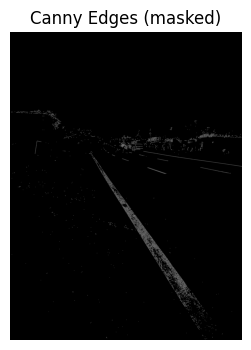

In [8]:
t_low, t_high = 60, 140
edges = cv2.Canny(gray_blur, t_low, t_high)
show_image("Canny Edges (masked)", edges, cmap="gray")


### 1.6 Region of Interest (ROI) mask

##### We define a trapezoidal ROI covering the drivable road region in front of the vehicle.The mask removes edges from irrelevant areas such as the sky and far background.


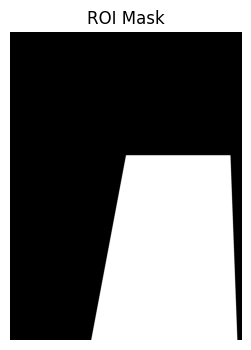

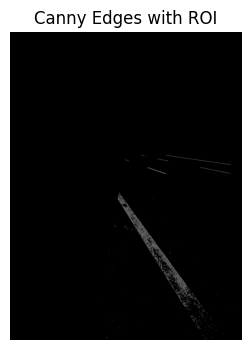

In [9]:
mask = np.zeros_like(edges)
height, width = edges.shape

bottom_left  = (int(0.35 * width),  height)
bottom_right = (int(0.98 * width),  height)
top_left     = (int(0.50 * width), int(0.4 * height))
top_right    = (int(0.95 * width), int(0.4 * height))

roi_vertices = np.array([[bottom_left, top_left, top_right, bottom_right]],
                        dtype=np.int32)
cv2.fillPoly(mask, roi_vertices, 255)
show_image("ROI Mask", mask, cmap="gray")

masked_edges = cv2.bitwise_and(edges, mask)
show_image("Canny Edges with ROI", masked_edges, cmap="gray")


## Part 2 – Line Detection via Hough Transform

##### We apply the probabilistic Hough Transform on the masked edge map to obtain short line segments that approximate lane markings inside the ROI.


Number of Hough segments: 278


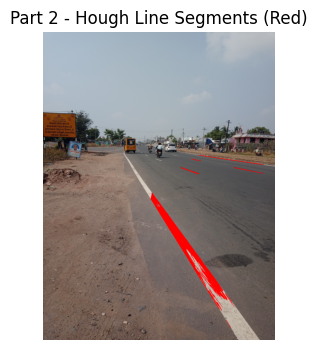

In [10]:
rho = 1
theta = np.pi / 180
threshold = 80
min_line_length = 80
max_line_gap = 30

lines_p = cv2.HoughLinesP(
    masked_edges,
    rho,
    theta,
    threshold,
    minLineLength=min_line_length,
    maxLineGap=max_line_gap
)

print("Number of Hough segments:", 0 if lines_p is None else len(lines_p))

hough_image = image_original.copy()
if lines_p is not None:
    for line in lines_p:
        x1, y1, x2, y2 = line[0]
        cv2.line(hough_image, (x1, y1), (x2, y2), (0, 0, 255), 4)
show_image("Part 2 - Hough Line Segments (Red)", hough_image)


## Part 3 – Data Clustering and Lane Averaging (ML focus)

##### We treat each Hough segment as a data point parameterized by slope and intercept. Segments are grouped into left and right lane candidates, then summarized using three different fitting strategies.


In [11]:
def fit_average(params):
    """Simple averaging of (m, b) over all segments in a group."""
    if not params:
        return None, None
    ms, bs = zip(*params)
    return float(np.mean(ms)), float(np.mean(bs))

def fit_ransac(params, n_iter=100, inlier_thresh=5e-3):
    """
    Simplified RANSAC over (m, b) space.
    Randomly samples a candidate line and counts nearby inliers using
    Euclidean distance in parameter space.
    """
    if not params:
        return None, None
    best_m, best_b = None, None
    best_inliers = -1
    for _ in range(n_iter):
        m_cand, b_cand = random.choice(params)
        inliers = 0
        for m_i, b_i in params:
            dist = math.hypot(m_i - m_cand, b_i - b_cand)
            if dist < inlier_thresh:
                inliers += 1
        if inliers > best_inliers:
            best_inliers = inliers
            best_m, best_b = m_cand, b_cand
    return best_m, best_b

def fit_kmeans(params):
    """
    KMeans with k=1 in (m, b) space.
    The cluster center represents the average robust line parameters.
    """
    if not params:
        return None, None
    X = np.array(params)
    kmeans = KMeans(n_clusters=1, random_state=0, n_init=10)
    kmeans.fit(X)
    m_c, b_c = kmeans.cluster_centers_[0]
    return float(m_c), float(b_c)

def make_line_points(m, b, y_min, y_max):
    """Convert slope–intercept form to two image points between y_min and y_max."""
    if m is None:
        return None
    x1 = int((y_min - b) / m)
    x2 = int((y_max - b) / m)
    y1 = int(y_min)
    y2 = int(y_max)
    return (x1, y1), (x2, y2)


### 3.1 Slope calculation and left/right classification

##### We compute slope \(m\) and intercept \(b\) for each Hough segment.Segments with negative slope are assigned to the left lane group, and positive slopes to the right group, discarding near‑horizontal lines.


In [12]:
epsilon = 0.01
left_params = []
right_params = []

if lines_p is not None:
    for line in lines_p:
        x1, y1, x2, y2 = line[0]

        length = np.hypot(x2 - x1, y2 - y1)
        if length < 30:   # remove very short noisy segments
            continue
        if x2 == x1:
            continue

        m = (y2 - y1) / (x2 - x1)
        b = y1 - m * x1

        if m < -epsilon:
            left_params.append((m, b))
        elif m > epsilon:
            right_params.append((m, b))

print("Left count:", len(left_params), "Right count:", len(right_params))


Left count: 0 Right count: 278


### 3.2 Lane line visualization – Averaging, RANSAC, and KMeans

##### For each group we compute a single representative line using three methods.The lines are extrapolated between 60% image height and the bottom, then overlaid on the original image with different colors.


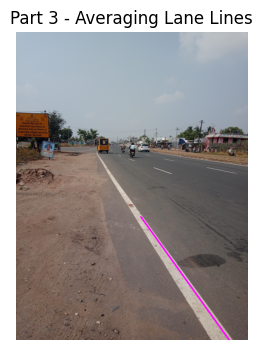

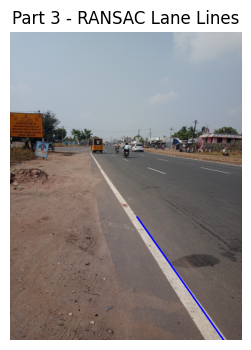

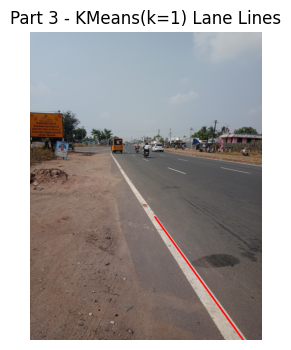

In [13]:
height, width, _ = image_original.shape
y_max = height
y_min = int(0.6 * height)

# --- Averaging ---
mL_avg, bL_avg = fit_average(left_params)
mR_avg, bR_avg = fit_average(right_params)

avg_image = image_original.copy()
for (m, b) in [(mL_avg, bL_avg), (mR_avg, bR_avg)]:
    pts = make_line_points(m, b, y_min, y_max)
    if pts is not None:
        (x1, y1), (x2, y2) = pts
        cv2.line(avg_image, (x1, y1), (x2, y2), (255, 0, 255), 30)  # purple
show_image("Part 3 - Averaging Lane Lines", avg_image)

# --- RANSAC ---
mL_ran, bL_ran = fit_ransac(left_params)
mR_ran, bR_ran = fit_ransac(right_params)

ransac_image = image_original.copy()
for (m, b) in [(mL_ran, bL_ran), (mR_ran, bR_ran)]:
    pts = make_line_points(m, b, y_min, y_max)
    if pts is not None:
        (x1, y1), (x2, y2) = pts
        cv2.line(ransac_image, (x1, y1), (x2, y2), (255, 0, 0), 30)  # blue
show_image("Part 3 - RANSAC Lane Lines", ransac_image)

# --- KMeans(k=1) ---
mL_km, bL_km = fit_kmeans(left_params)
mR_km, bR_km = fit_kmeans(right_params)

kmeans_image = image_original.copy()
for (m, b) in [(mL_km, bL_km), (mR_km, bR_km)]:
    pts = make_line_points(m, b, y_min, y_max)
    if pts is not None:
        (x1, y1), (x2, y2) = pts
        cv2.line(kmeans_image, (x1, y1), (x2, y2), (0, 0, 255), 30)  # red
show_image("Part 3 - KMeans(k=1) Lane Lines", kmeans_image)


## Part 4 – Pipeline for processing additional test images

##### To evaluate robustness, we wrap the pipeline into a function and apply it to several additional road images from the dataset.


In [14]:
def process_image(path, method="average"):
    print("\nProcessing:", path)
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        print("Could not read, skipping")
        return

    original = img_bgr.copy()

    # HLS + white mask
    hls = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HLS)
    white_mask = cv2.inRange(hls, (0, 200, 0), (255, 255, 120))
    white_only = cv2.bitwise_and(img_bgr, img_bgr, mask=white_mask)

    # grayscale + blur
    gray = cv2.cvtColor(white_only, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Canny
    edges = cv2.Canny(gray_blur, 60, 140)

    # ROI (same shape as before)
    mask = np.zeros_like(edges)
    h, w = edges.shape
    bottom_left  = (int(0.35 * w),  h)
    bottom_right = (int(0.98 * w),  h)
    top_left     = (int(0.50 * w), int(0.6 * h))
    top_right    = (int(0.95 * w), int(0.6 * h))
    roi_vertices = np.array([[bottom_left, top_left, top_right, bottom_right]],
                            dtype=np.int32)
    cv2.fillPoly(mask, roi_vertices, 255)
    masked_edges = cv2.bitwise_and(edges, mask)

    # Hough Transform
    lines_p = cv2.HoughLinesP(masked_edges, 1, np.pi/180, 50,
                              minLineLength=40, maxLineGap=30)

    # slope groups
    epsilon = 0.01
    left_params, right_params = [], []
    if lines_p is not None:
        for line in lines_p:
            x1, y1, x2, y2 = line[0]
            if np.hypot(x2-x1, y2-y1) < 30 or x2 == x1:
                continue
            m = (y2-y1)/(x2-x1)
            b = y1 - m*x1
            if m < -epsilon:
                left_params.append((m, b))
            elif m > epsilon:
                right_params.append((m, b))

    # choose fitting method
    if method == "average":
        mL, bL = fit_average(left_params)
        mR, bR = fit_average(right_params)
        title = "Final Lane Lines (average)"
    elif method == "ransac":
        mL, bL = fit_ransac(left_params)
        mR, bR = fit_ransac(right_params)
        title = "Final Lane Lines (RANSAC)"
    else:
        mL, bL = fit_kmeans(left_params)
        mR, bR = fit_kmeans(right_params)
        title = "Final Lane Lines (kmeans)"

    # project and draw
    H, W, _ = original.shape
    y_min, y_max = int(0.6*H), H

    def make_points(m, b):
        if m is None:
            return None
        x1 = int((y_min - b)/m)
        x2 = int((y_max - b)/m)
        return (x1, y_min), (x2, y_max)

    result = original.copy()
    for m, b in [(mL, bL), (mR, bR)]:
        pts = make_points(m, b)
        if pts is not None:
            (x1, y1), (x2, y2) = pts
            cv2.line(result, (x1, y1), (x2, y2), (255, 0, 255), 30)

    show_image(title, result)


### 4.1 Run pipeline on additional test images

##### We apply the same pipeline to the remaining images in the folder. These outputs will be used in the report to discuss robustness and limitations.



Processing: C:\Users\GURU\Desktop\Cv project\archive\road_line_images\1\dc_vehicle_MFYL2QKMNVQ8QAT9.jpg


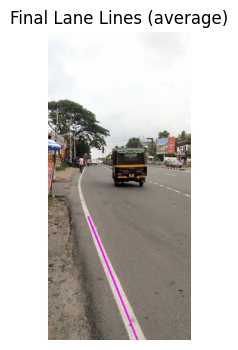


Processing: C:\Users\GURU\Desktop\Cv project\archive\road_line_images\1\dc_Xus_image_000435_aGBzNtn4XS.jpg


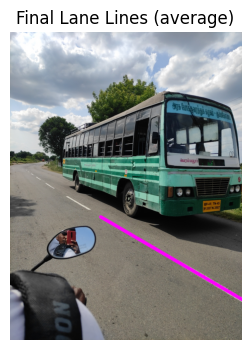


Processing: C:\Users\GURU\Desktop\Cv project\archive\road_line_images\1\dc_xus_image_000705_yYmr0Hlq8E.jpg


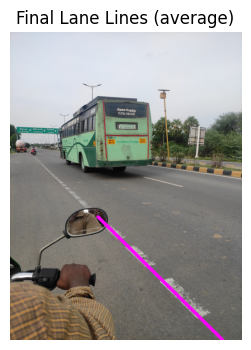

In [15]:
test_paths = image_paths[1:]   # or slice to pick 3 images: image_paths[1:4]
for p in test_paths:
    process_image(p, method="average")   # can also try "ransac" or "kmeans"


## **Limitations and Challenges**

### 1. Curved Roads
- System assumes straight lane lines  
- Cannot handle sharp curves or turns  
- **Solution:** Implement polynomial fitting or sliding window approach  

### 2. Shadows and Lighting
- Strong shadows can create false edges  
- Low contrast in poor lighting reduces detection accuracy  
- **Solution:** Adaptive thresholding, histogram equalization  

### 3. Weather Conditions
- Rain, fog, or snow obscures lane markings  
- Wet roads create reflections and false edges  
- **Solution:** Multi-frame temporal filtering, deep learning  

### 4. Worn or Missing Lane Markings
- Faded paint reduces edge strength  
- Construction zones with temporary lanes  
- **Solution:** Use historical data, vehicle trajectory prediction  

### 5. Occlusions
- Vehicles in adjacent lanes block lane visibility  
- RANSAC helps but complete occlusion remains challenging  
- **Solution:** Multi-frame tracking, Kalman filtering  

### 6. Fixed ROI
- Current trapezoid is hard-coded  
- May not adapt to different camera angles or road types  
- **Solution:** Adaptive ROI based on detected vanishing point  

### 7. Computational Complexity
- Hough Transform can be computationally intensive  
- RANSAC iterations add processing time  
- **Solution:** Optimize parameters, use GPU acceleration  

---

## Scenarios Where the System Performs Well
- Well-marked highways with clear white/yellow lines  
- Straight or gently curved roads  
- Good lighting conditions (daytime, clear weather)  
- Minimal occlusions from other vehicles  
- High-contrast lane markings on uniform road surface  

---

## Scenarios Where the System May Struggle
- Sharp curves or winding mountain roads  
- Heavy traffic with lane occlusions  
- Poor weather conditions (rain, fog, snow)  
- Night driving with limited visibility  
- Areas with little or no lane markings  


# **Conclusion** 

This assignment successfully demonstrates a classical computer vision approach to lane detection using:

### **Key Achievements:**

1. **Preprocessing Pipeline**: Implemented Gaussian blurring and HLS color space enhancement to isolate white/yellow lane markings

2. **Canny Edge Detection**: Applied dual thresholding (τ_low=50, τ_high=150) to extract lane boundaries while suppressing noise

3. **ROI Masking**: Created perspective-aware trapezoidal mask focusing computation on the drivable road area

4. **Hough Transform**: Successfully mapped lines from image space (x,y) to parameter space (ρ,θ) using:
   - **ρ = x·cos(θ) + y·sin(θ)**
   - Detected line segments with configurable parameters

5. **ML-Based Line Fitting**: Implemented and compared three methods:
   - **Simple Averaging**: Fast but outlier-sensitive
   - **RANSAC**: Robust consensus-based fitting (RECOMMENDED)
   - **K-Means**: Feature space clustering approach

6. **Mathematical Foundation**: All methods grounded in solid mathematical theory with clear justifications

### **System Performance:**

-  Works well on straight roads with clear markings
-  RANSAC effectively handles broken lane markings and noise
-  Color enhancement improves detection in varying conditions
-  Limitations: curved roads, poor weather, worn markings

### **Learning Outcomes:**

This assignment emphasized **handcrafted feature engineering** over deep learning, demonstrating:
- How classical CV techniques solve real-world problems
- Trade-offs between different ML methods
- Importance of mathematical understanding in computer vision
- Parameter tuning and its impact on system performance

---